# 4 — Across resolutions

The deviation network is fully convolutional, so a model trained at one
resolution can be applied at another one without retraining. Here the model
trained at $128\times128$ is evaluated on the same held-out Mayo slice at
$128\times128$ (the training resolution) and at its native resolution
$512\times512$. Run `main.py` first.

Figures and the table are saved in `plots/` (prefix `4_`).

In [1]:
import numpy as np
import torch

from utils.experiments import (build_test_instance, reference_solution, run_fbs,
                               objective_gap, load_model)
from utils.plots import apply_paper_style, plot_curves, show_images

apply_paper_style()

In [ ]:
# --- configuration (must match main.py) ---------------------------------------
TRAIN_SIZE = 128           # resolution of the training run
TEST_SIZES = [128, 512]    # resolutions of the evaluation (a cache is needed for each)
N_ANGLES = 180
NOISE_LEVEL = 0.05
GAMMA = 2
PRIMAL_STEP = 1            # primal step tau (see main.py)

TEST_PATIENT = "L014"      # never used for training or validation
TEST_SLICE = 0
MAYO_CACHE_DIR = "./data/mayo_cache_{}"                # one cache per resolution
CKPT = f"kkt_tomo_{TRAIN_SIZE}_gamma_2_objective_alpha_04.pt"    # written by main.py

T_TRAIN = 10               # unrolling horizon used in training
T_LONG = 100               # length of the convergence curves
T_REF = 6000               # length of the run that defines F* (cached in results/)

## Runs

The same weights are loaded at every resolution: only the operators change.

In [3]:
results, refs, instances = {}, {}, {}
for size in TEST_SIZES:
    inst = build_test_instance(size, N_ANGLES, NOISE_LEVEL, GAMMA, TEST_PATIENT, TEST_SLICE,
                               MAYO_CACHE_DIR.format(size), primal_step=PRIMAL_STEP)
    ref = reference_solution(inst, T_REF)
    print(f"{size}x{size}: F* = {ref['f_star']:.4f}, "
          f"PSNR of the TGV2 solution = {ref['psnr']:.2f} dB")
    model, _ = load_model(CKPT, inst, T=T_TRAIN)
    results[size] = {
        "Zero deviation": run_fbs(inst, T_LONG, snapshots=(T_TRAIN,)),
        "Learned": run_fbs(inst, T_LONG, model, snapshots=(T_TRAIN,)),
    }
    refs[size], instances[size] = ref, inst

128x128: F* = 0.6605, PSNR of the TGV2 solution = 26.81 dB


512x512: F* = 8.0576, PSNR of the TGV2 solution = 26.41 dB


## Convergence at each resolution

128x128


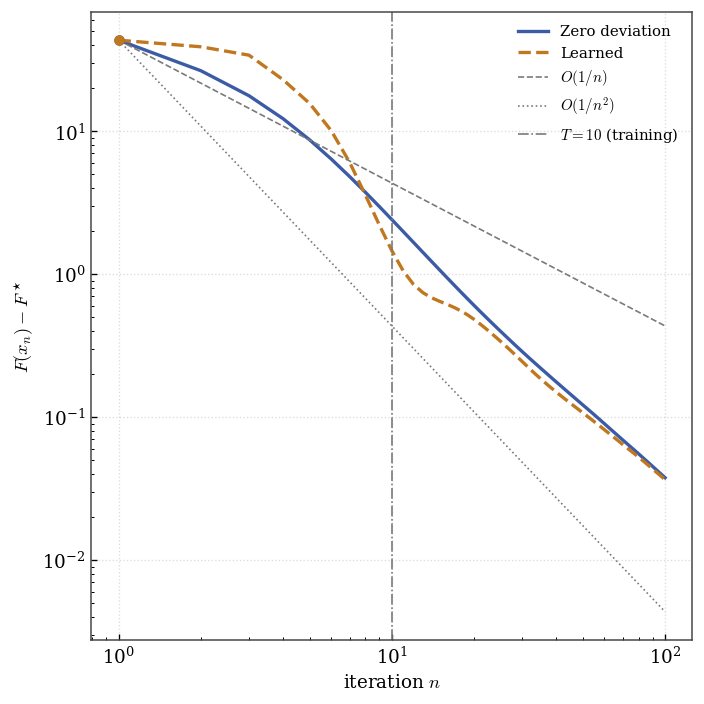

512x512


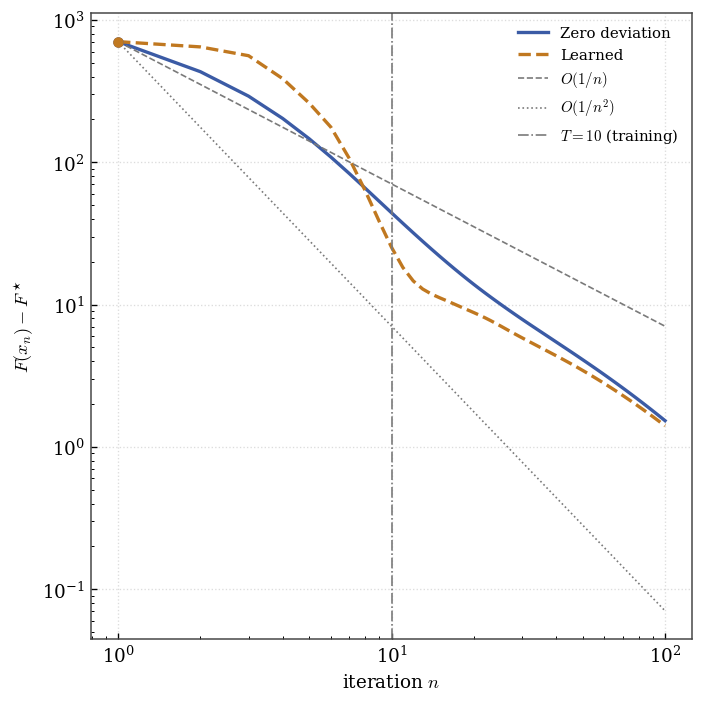

In [4]:
gaps = {size: {label: objective_gap(r, refs[size]["f_star"]) for label, r in results[size].items()}
        for size in TEST_SIZES}
for size in TEST_SIZES:
    print(f"{size}x{size}")
    plot_curves(gaps[size], r"$F(x_n) - F^\star$", f"4_objective_gap_{size}", slopes=True,
                horizon=T_TRAIN, iteration_start=0, show=True)

## Gain across resolutions

Objective gap of the learned scheme divided by the gap of the zero-deviation
baseline at the same iteration. Below 1, the learned scheme is ahead.

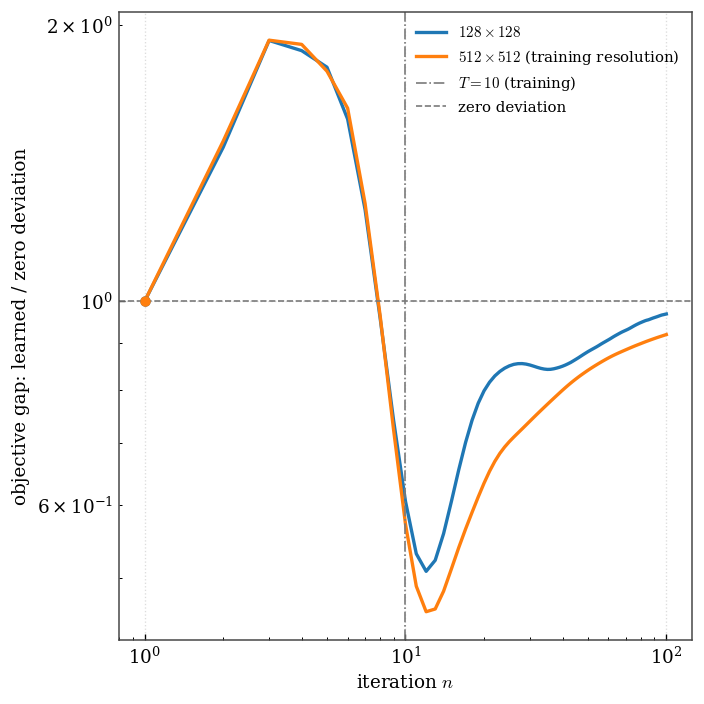

In [5]:
ratios = {rf"${size}\times{size}$" + (" (training resolution)" if size == TRAIN_SIZE else ""):
          gaps[size]["Learned"] / gaps[size]["Zero deviation"] for size in TEST_SIZES}
plot_curves(ratios, "objective gap: learned / zero deviation", "4_gap_ratio",
            horizon=T_TRAIN, hline=(1.0, "zero deviation"), iteration_start=0, show=True)

## PSNR

128x128


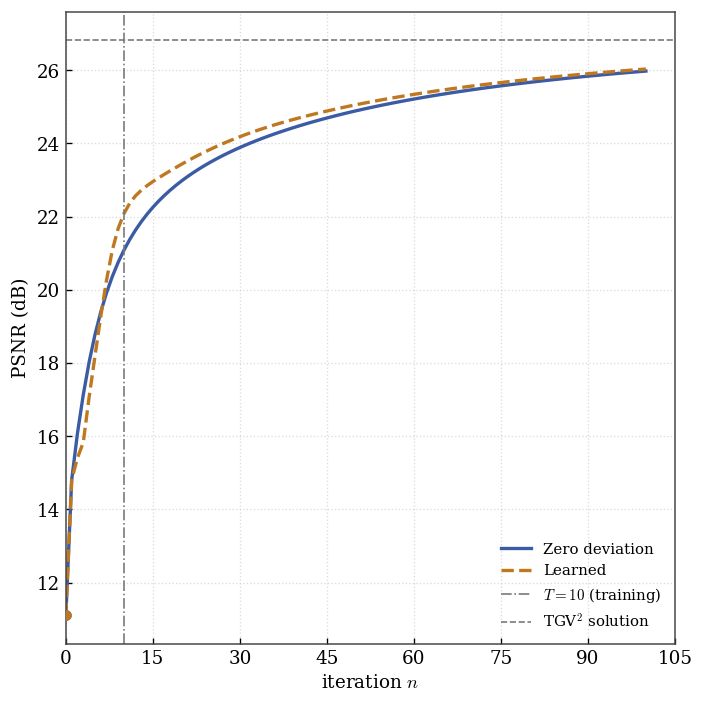

512x512


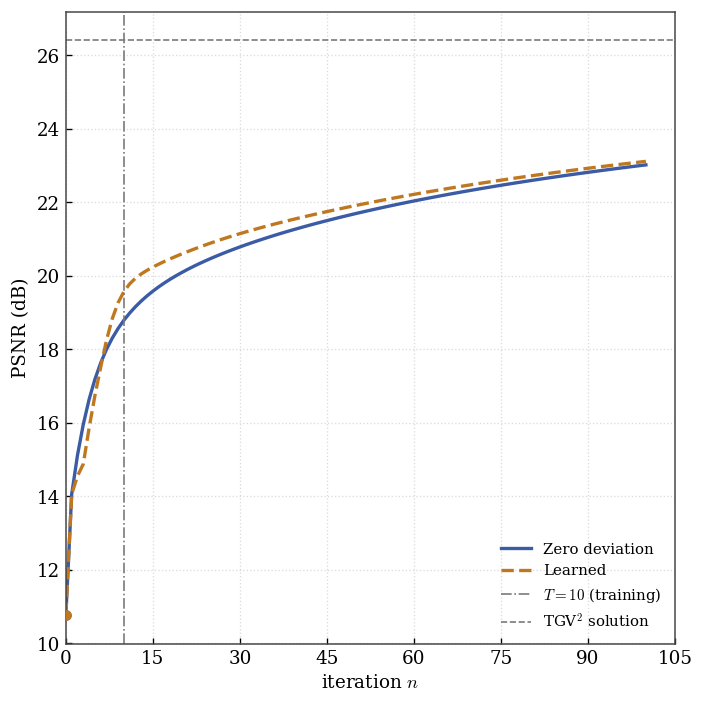

In [6]:
for size in TEST_SIZES:
    print(f"{size}x{size}")
    plot_curves({label: r["psnr"] for label, r in results[size].items()}, "PSNR (dB)",
                f"4_psnr_{size}", loglog=False, horizon=T_TRAIN,
                hline=(refs[size]["psnr"], r"TGV$^2$ solution"), iteration_start=0, show=True)

## Reconstructions

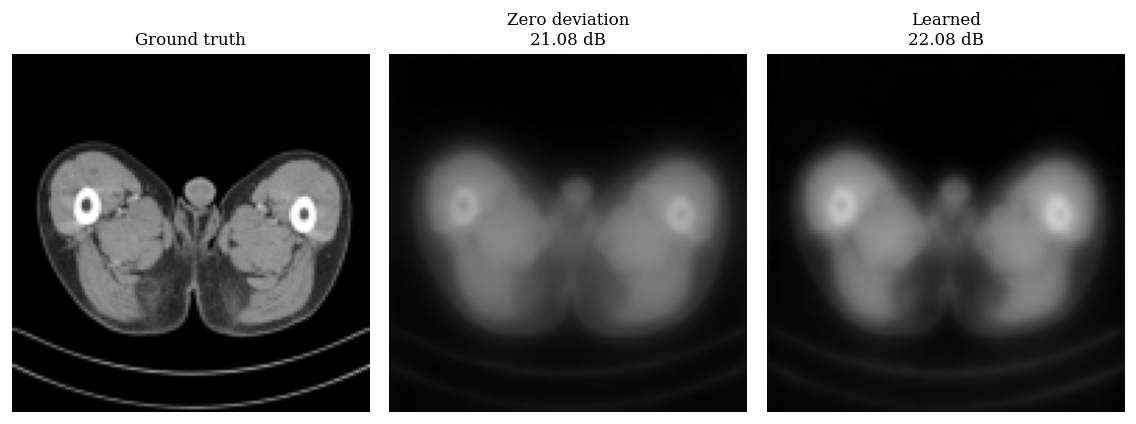

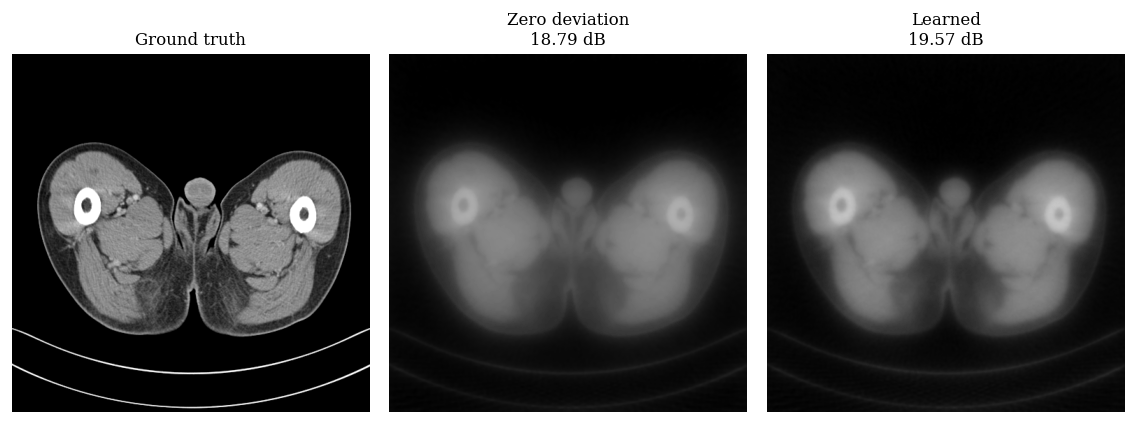

In [7]:
def gallery(size, n):
    """Ground truth and the reconstruction of every method after n iterations."""
    images = {"Ground truth": instances[size]["clean"]}
    for label, r in results[size].items():
        images[f"{label}\n{r['psnr'][n]:.2f} dB"] = r["images"][n]
    return images

for size in TEST_SIZES:
    show_images(gallery(size, T_TRAIN), f"4_reconstructions_{size}_{T_TRAIN}_iterations", show=True)

## Summary

Objective gap and PSNR after 10, 20 and 100 iterations, and the first
iteration from which the learned scheme stays ahead of the baseline. The table
is also written as LaTeX in `plots/`.

In [8]:
import os
import pandas as pd

rows = []
for size in TEST_SIZES:
    ahead = gaps[size]["Learned"] < gaps[size]["Zero deviation"]
    behind = np.flatnonzero(~ahead)
    first_ahead = int(behind[-1]) + 1 if len(behind) else 0     # index = iteration (x_0 at 0)
    for label, r in results[size].items():
        row = {"Resolution": f"{size}x{size}", "Method": label}
        for n in (10, 20, 100):
            row[f"Gap, {n} it."] = f"{gaps[size][label][n]:.3g}"
            row[f"PSNR, {n} it. (dB)"] = f"{r['psnr'][n]:.2f}"
        row["Time / iteration (ms)"] = f"{r['ms_per_iter']:.0f}"
        row["Ahead from iteration"] = first_ahead if label == "Learned" else ""
        rows.append(row)
table = pd.DataFrame(rows).set_index(["Resolution", "Method"])

os.makedirs("plots", exist_ok=True)
with open(os.path.join("plots", "4_resolution_comparison.tex"), "w") as file:
    file.write(table.to_latex(escape=True))
table

Gap, 10 it. PSNR, 10 it. (dB) Gap, 20 it.  \
Resolution Method                                                     
128x128    Zero deviation        2.41             21.08       0.605   
           Learned               1.46             22.08       0.483   
512x512    Zero deviation        44.1             18.79        13.9   
           Learned               25.2             19.57        8.78   

                          PSNR, 20 it. (dB) Gap, 100 it. PSNR, 100 it. (dB)  \
Resolution Method                                                             
128x128    Zero deviation             22.98       0.0377              25.97   
           Learned                    23.43       0.0365              26.03   
512x512    Zero deviation             20.09         1.53              23.02   
           Learned                    20.60         1.41              23.11   

                          Time / iteration (ms) Ahead from iteration  
Resolution Method                                                     
128x128    Zero deviation                     6                       
           Learned                           18                    8  
512x512    Zero deviation                    27                       
           Learned                           92                    8